## Feature Engineering 

This notebook builds and validates the derived features required for the elasticity model.<br>
We construct a logarithmic price transformation to enable <b><i>log-log regression</b><i>, extract <b><i>ISO week numbers</b><i> to capture seasonality, and create a <b><i>Q4 flag</b><i> to explicitly control for the peak season.<br>
We visualise each feature to ensure it behaves as expected before being implemented in the main pipeline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import random
%matplotlib inline
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import sys
import os
sys.path.append(os.path.abspath('..'))  # adds project root to path

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from src.data_cleaning import clean_data
from src.product_categorisation import categorise_products

# Set plotting style for a clean, professional look
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load the raw data and apply data cleaning steps

raw_df = pd.read_csv('../data/raw/online_retail_II.csv')
cleaned_df = clean_data(raw_df)
df = categorise_products(cleaned_df)

In [2]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,date,year,month,week,Revenue,category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,2009-12-01,2009,12,49,83.40,Seasonal & Festive
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009-12-01,2009,12,49,81.00,Other
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,2009-12-01,2009,12,49,81.00,Other
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,2009-12-01,2009,12,49,100.80,Home Decor & Accessories
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,2009-12-01,2009,12,49,30.00,Home Decor & Accessories


## 1. Log Price

Price elasticity is estimated using an <b>Ordinary Least Squares (OLS) regression</b>. <br>
We need the natural logarithm of the unit price to achieve this. The visualisation checks the distribution to confirm the transformation produces an approximately symmetric distribution within segments.

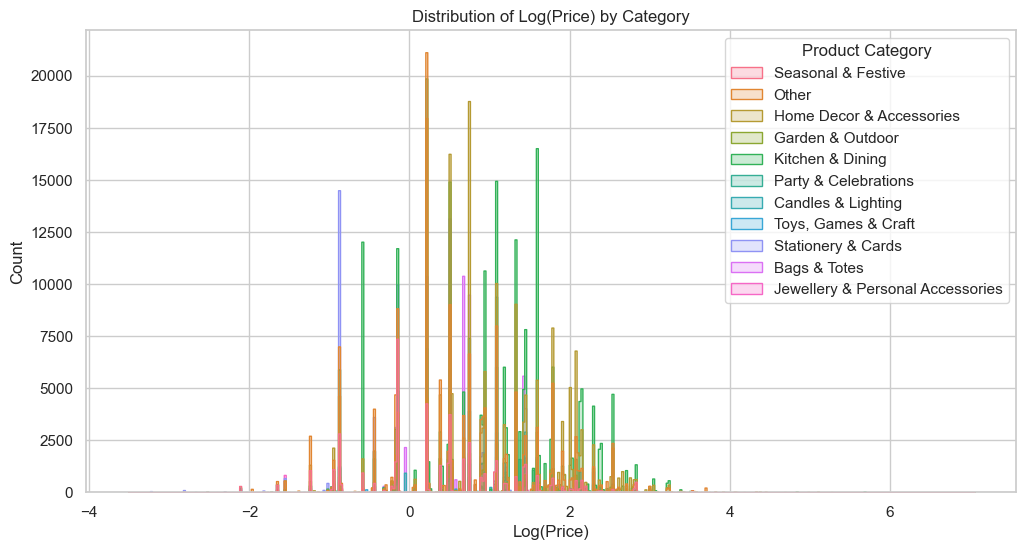

In [3]:
df['log_price'] = np.log(df['Price'])

plt.figure(figsize=(12, 6))
ax = sns.histplot(data=df, x='log_price', hue='category', element='step', common_norm=False)
plt.title('Distribution of Log(Price) by Category')
plt.xlabel('Log(Price)')
plt.ylabel('Count')
ax.get_legend().set_title("Product Category")
plt.show();

<ul><li>The log transformation yields approximately symmetric distributions for prices within each category. 
<li>This normalisation justifies our use of a log-log OLS specification for the elasticity model.</ul>

## 2. ISO Week Number

To control for seasonality, we use the `week` feature (ISO week number) generated during the data cleaning stage. <br>The bar chart below reveals the structural seasonality of the data across the calendar year and highlights peak trading periods.

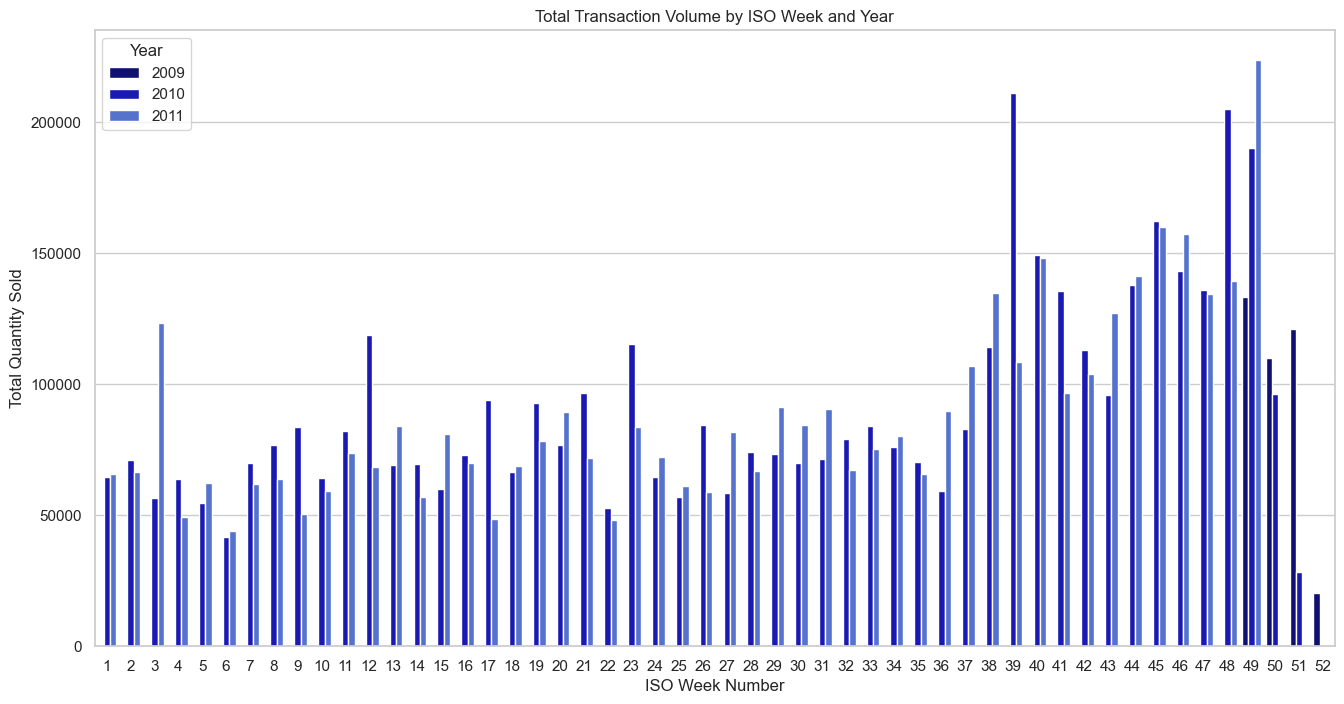

In [4]:
weekly_volume = df.groupby(['year', 'week'])['Quantity'].sum().reset_index()

plt.figure(figsize=(16, 8))
sns.barplot(data=weekly_volume, x='week', y='Quantity', hue='year', palette=['#000080', '#0000CD', '#4169E1'])
plt.title('Total Transaction Volume by ISO Week and Year')
plt.xlabel('ISO Week Number')
plt.ylabel('Total Quantity Sold')
plt.legend(title='Year')
plt.show();

## 3. Q4 Flag

We often observe that the final quarter of the year (the golden quarter) behaves differently from the rest of the year. The chart in the previous section confirms this.<br>
We will add a binary flag (`is_q4`) to control for this seasonal spike.

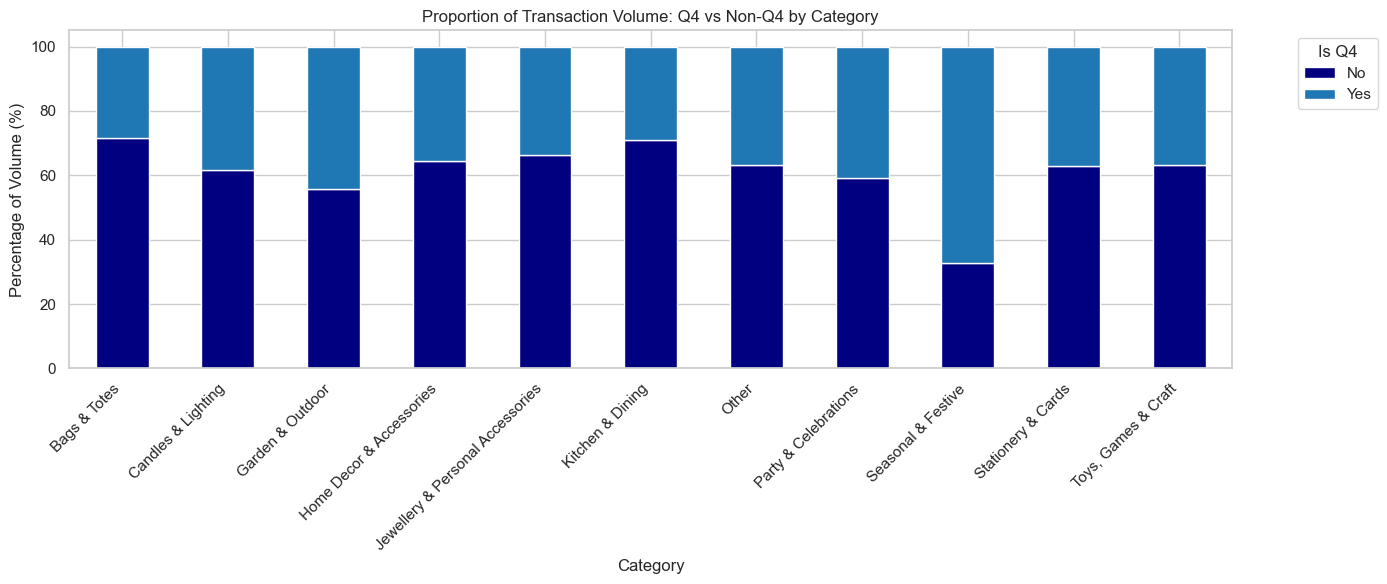

In [5]:
df['is_q4'] = df['week'].between(40, 52).astype(int)

q4_share = df.groupby(['category', 'is_q4'])['Quantity'].sum().unstack()
q4_share = q4_share.div(q4_share.sum(axis=1), axis=0) * 100

q4_share.rename(columns={0: 'No', 1: 'Yes'}, inplace=True)

q4_share.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#000080', '#1f77b4'])
plt.title('Proportion of Transaction Volume: Q4 vs Non-Q4 by Category')
plt.xlabel('Category')
plt.ylabel('Percentage of Volume (%)')
plt.legend(title='Is Q4', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();